In [81]:
import sys
from pathlib import Path
from datetime import datetime, timezone, timedelta
import numpy as np
import pandas as pd
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
import joblib

REPO_ROOT = Path.cwd().parent.parent
BACKEND_DIR = REPO_ROOT / "backend"
sys.path.insert(0, str(BACKEND_DIR))
sys.path.insert(0, str(Path.cwd()))

from _pool_common import (
    load_pool_data,
    build_pooled_train_stack,
    compute_metrics_averaged_over_windows,
    metrics_to_parquet,
    TEST_SIZE,
    FORECAST_HORIZON,
    ROLLING_STEP,
    MIN_TRAIN_STACK,
    ARTIFACTS_DIR,
    TICKERS,
)

LAG_RETURNS = 5
RSI_PERIOD = 14
MACD_FAST, MACD_SLOW, MACD_SIGNAL = 12, 26, 9
XGB_PARAMS = dict(n_estimators=100, max_depth=4, learning_rate=0.01, random_state=42)


def fetch_cnn_fear_greed_index(limit_days=500, start_date=None):
    """Fetch CNN Fear & Greed Index from production.dataviz.cnn.io (graphdata/{start_date}). Uses requests + expanded headers.
    If start_date is provided (str YYYY-MM-DD or datetime), use it so the range matches your symbol dataframe; else use now - limit_days."""
    if start_date is not None:
        start_date = pd.to_datetime(start_date).strftime("%Y-%m-%d")
    else:
        start_date = (datetime.now(timezone.utc) - timedelta(days=limit_days)).strftime("%Y-%m-%d")
    url = f"https://production.dataviz.cnn.io/index/fearandgreed/graphdata/{start_date}"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36",
        "Accept": "application/json",
        "Referer": "https://www.cnn.com/markets/fear-and-greed",
        "Origin": "https://www.cnn.com",
    }
    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code != 200:
            return pd.DataFrame(columns=["timestamp", "fear_greed"])
        data = response.json()
        fng_data = data.get("fear_and_greed_historical", {}).get("data") or []
        if not fng_data:
            return pd.DataFrame(columns=["timestamp", "fear_greed"])
        fng_df = pd.DataFrame(fng_data)
        fng_df["timestamp"] = pd.to_datetime(fng_df["x"] / 1000, unit="s").dt.normalize()
        fng_df = fng_df.rename(columns={"y": "fear_greed"})
        return fng_df[["timestamp", "fear_greed"]].drop_duplicates("timestamp").sort_values("timestamp")
    except requests.exceptions.JSONDecodeError:
        return pd.DataFrame(columns=["timestamp", "fear_greed"])
    except Exception:
        return pd.DataFrame(columns=["timestamp", "fear_greed"])

In [82]:
# Fear & Greed is fetched by fetch_cnn_fear_greed_index() in the cell above (CNN graphdata API, requests + headers).

In [83]:
def _rsi(series: pd.Series, period: int) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1 / period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False).mean()
    rs = avg_gain / np.where(avg_loss != 0, avg_loss, 1e-10)
    return 100 - (100 / (1 + rs))


def build_feature_df(grp: pd.DataFrame):
    """Same as stack: XGB features = VIX lag, cyclical month, fear_greed lag. Target = next 21 returns."""
    df = grp.sort_values("timestamp").copy()
    df["close"] = df["close"].astype(float)
    df["return"] = df["close"].pct_change()
    for i in range(1, LAG_RETURNS + 1):
        df[f"ret_lag_{i}"] = df["return"].shift(i)
    if "volume" in df.columns:
        df["volume_lag_1"] = df["volume"].astype(float).shift(1)
    else:
        df["volume_lag_1"] = np.nan
    df["rsi"] = _rsi(df["close"], RSI_PERIOD)
    ema_fast = df["close"].ewm(span=MACD_FAST, adjust=False).mean()
    ema_slow = df["close"].ewm(span=MACD_SLOW, adjust=False).mean()
    df["macd_line"] = ema_fast - ema_slow
    df["macd_signal"] = df["macd_line"].ewm(span=MACD_SIGNAL, adjust=False).mean()
    if "vix" in df.columns:
        df["vix_lag_1"] = df["vix"].astype(float).shift(1)
    else:
        df["vix_lag_1"] = np.nan
    df["month"] = pd.to_datetime(df["timestamp"]).dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    if "fear_greed" not in df.columns:
        df["fear_greed"] = 50.0
    else:
        df["fear_greed"] = df["fear_greed"].fillna(50.0)
    df["fear_greed_lag_1"] = df["fear_greed"].shift(1)
    for h in range(1, FORECAST_HORIZON + 1):
        df[f"target_{h}"] = df["return"].shift(-h)
    feature_cols_lstm = [f"ret_lag_{i}" for i in range(1, LAG_RETURNS + 1)] + [
        "volume_lag_1", "rsi", "macd_line", "macd_signal"
    ]
    feature_cols_xgb = ["vix_lag_1", "month_sin", "month_cos", "fear_greed_lag_1"]
    target_cols = [f"target_{h}" for h in range(1, FORECAST_HORIZON + 1)]
    base_cols = ["timestamp", "close", "return"] + feature_cols_lstm + feature_cols_xgb + target_cols
    out = df[[c for c in base_cols if c in df.columns]].copy()
    return out.dropna(), feature_cols_lstm, feature_cols_xgb, target_cols


def train_global_xgb(stacked: pd.DataFrame, horizon: int):
    """Train one XGB on pooled data (all assets, only rows before 60-day test window). Returns dict for predict_xgb_global."""
    pooled = build_pooled_train_stack(stacked, TEST_SIZE, MIN_TRAIN_STACK)
    if pooled.empty:
        return None
    feat_dfs = []
    for sym in pooled["symbol"].unique():
        grp = pooled[pooled["symbol"] == sym].copy()
        try:
            feat_df, _, feature_cols_xgb, target_cols = build_feature_df(grp)
        except Exception:
            continue
        if len(feat_df) < MIN_TRAIN_STACK + horizon:
            continue
        feat_dfs.append(feat_df)
    if not feat_dfs:
        return None
    pooled_feat = pd.concat(feat_dfs, ignore_index=True)
    X = pooled_feat[feature_cols_xgb].values.astype(np.float32)
    y = pooled_feat[target_cols].values.astype(np.float32)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    xgb_multi = MultiOutputRegressor(XGBRegressor(**XGB_PARAMS))
    xgb_multi.fit(X_s, y)
    return {"model": xgb_multi, "scaler": scaler, "feature_cols_xgb": feature_cols_xgb}


def predict_xgb_global(context_df: pd.DataFrame, horizon: int, global_xgb: dict) -> list:
    """Predict 21 price steps using pre-trained global XGB; no training."""
    if global_xgb is None:
        return []
    try:
        feat_df, _, feature_cols_xgb, _ = build_feature_df(context_df)
    except Exception:
        return []
    if len(feat_df) < 1:
        return []
    X = feat_df[feature_cols_xgb].values.astype(np.float32)
    X_s = global_xgb["scaler"].transform(X)
    last_row = X_s[-1:]
    pred_returns = global_xgb["model"].predict(last_row).ravel()
    p0 = float(context_df["close"].iloc[-1])
    prices = p0 * np.cumprod(np.concatenate([[1.0], 1.0 + pred_returns]))[1:]
    return [float(p) for p in prices[:horizon]]

In [84]:
stacked = load_pool_data(with_vix=True, with_volume=True)
symbol_start = pd.to_datetime(stacked["timestamp"]).min().strftime("%Y-%m-%d")
fear_greed_df = fetch_cnn_fear_greed_index(start_date=symbol_start)
if not fear_greed_df.empty:
    stacked["date"] = pd.to_datetime(stacked["timestamp"]).dt.normalize()
    fear_greed_df["date"] = pd.to_datetime(fear_greed_df["timestamp"]).dt.normalize()
    stacked = stacked.merge(fear_greed_df[["date", "fear_greed"]], on="date", how="left")
    stacked["fear_greed"] = stacked["fear_greed"].ffill().bfill()
    stacked = stacked.drop(columns=["date"])
print(stacked.groupby("symbol").size())
stacked.head(10)

symbol
AAPL     1256
AMZN     1256
GOOGL    1256
JNJ      1256
JPM      1256
MSFT     1256
NVDA     1256
SPY      1256
WMT      1256
XOM      1256
dtype: int64


,timestamp,symbol,close,volume,vix,fear_greed
0,2021-03-08,AAPL,116.360001,154376600,25.469999,39.080000
1,2021-03-09,AAPL,121.089996,129525800,24.030001,43.360000
2,2021-03-10,AAPL,119.980003,111943300,22.559999,45.560000
3,2021-03-11,AAPL,121.959999,103026500,21.910000,50.480000
4,2021-03-12,AAPL,121.029999,88105100,20.690001,53.720000
5,2021-03-15,AAPL,123.989998,92403800,20.030001,56.520000
6,2021-03-16,AAPL,125.570000,115227900,19.790001,54.800000
7,2021-03-17,AAPL,124.760002,111932600,19.230000,57.866667
8,2021-03-18,AAPL,120.529999,121229700,21.580000,52.333333
9,2021-03-19,AAPL,119.989998,185549500,20.950001,50.833333


In [85]:
fear_greed_df.head()

,timestamp,fear_greed,date
0,2021-03-08,39.08,2021-03-08
1,2021-03-09,43.36,2021-03-09
2,2021-03-10,45.56,2021-03-10
3,2021-03-11,50.48,2021-03-11
4,2021-03-12,53.72,2021-03-12


In [86]:
# Train once on pooled data (all assets, only rows before 60-day test window)
global_xgb = train_global_xgb(stacked, FORECAST_HORIZON)
print("Global XGB trained on", len(build_pooled_train_stack(stacked, TEST_SIZE, MIN_TRAIN_STACK)), "pooled train rows.")

Global XGB trained on 11960 pooled train rows.


In [87]:
model_name = "xgboost"
all_preds = []
for sym in TICKERS:
    grp = stacked[stacked["symbol"] == sym].copy()
    if grp.empty:
        continue
    grp = grp.sort_values("timestamp").reset_index(drop=True)
    prices = grp.set_index("timestamp")["close"].astype(float).dropna()
    n = len(prices)
    if n < TEST_SIZE + MIN_TRAIN_STACK:
        continue
    split_idx = n - TEST_SIZE
    test_index = prices.index[split_idx:]
    test_values = prices.values[split_idx:]
    preds = []
    window_ix = 0
    start = 0
    while start + FORECAST_HORIZON <= TEST_SIZE:
        context_cols = ["timestamp", "close", "vix"] + [c for c in ["volume", "fear_greed"] if c in grp.columns]
        context_df = grp.iloc[: split_idx + start][context_cols].copy()
        if len(context_df) < MIN_TRAIN_STACK:
            start += ROLLING_STEP
            continue
        price_list = predict_xgb_global(context_df, FORECAST_HORIZON, global_xgb)
        if not price_list or len(price_list) < FORECAST_HORIZON:
            start += ROLLING_STEP
            window_ix += 1
            continue
        for h in range(FORECAST_HORIZON):
            idx = start + h
            ts = test_index[idx]
            y_true = float(test_values[idx])
            y_pred = float(price_list[h])
            preds.append({"timestamp": ts, "y_true": y_true, "y_pred": y_pred, "window_ix": window_ix})
        window_ix += 1
        start += ROLLING_STEP
    if preds:
        pred_df = pd.DataFrame(preds)
        pred_df["symbol"] = sym
        all_preds.append(pred_df)

pred_xgb = pd.concat(all_preds, ignore_index=True) if all_preds else pd.DataFrame(
    columns=["timestamp", "y_true", "y_pred", "window_ix", "symbol"]
)
print(pred_xgb.groupby("symbol").size() if not pred_xgb.empty else "No predictions.")
pred_xgb.head()

symbol
AAPL     126
AMZN     126
GOOGL    126
JNJ      126
JPM      126
MSFT     126
NVDA     126
SPY      126
WMT      126
XOM      126
dtype: int64


,timestamp,y_true,y_pred,window_ix,symbol
0,2025-12-09,277.179993,278.284194,0,AAPL
1,2025-12-10,278.779999,278.520459,0,AAPL
2,2025-12-11,278.029999,278.879375,0,AAPL
3,2025-12-12,278.279999,279.828554,0,AAPL
4,2025-12-15,274.109985,280.061961,0,AAPL


In [88]:
metrics_rows = []
for sym in pred_xgb["symbol"].unique():
    sub = pred_xgb[pred_xgb["symbol"] == sym]
    m = compute_metrics_averaged_over_windows(sub)
    metrics_rows.append({"model": model_name, "symbol": sym, **m})
m_overall = compute_metrics_averaged_over_windows(pred_xgb)
metrics_rows.append({"model": model_name, "symbol": "overall", **m_overall})

metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df.to_string())
metrics_to_parquet(metrics_rows, ARTIFACTS_DIR / "metrics_xgboost_pool.parquet")
print("Saved:", ARTIFACTS_DIR / "metrics_xgboost_pool.parquet")

      model   symbol        MAE       RMSE    MAPE_%
0   xgboost     AAPL  11.025909  13.303582  4.185563
1   xgboost     MSFT  26.574246  31.026122  6.223174
2   xgboost    GOOGL  13.597635  15.386184  4.257703
3   xgboost     AMZN  13.800689  16.240423  6.317007
4   xgboost      JPM  10.633022  12.421191  3.422774
5   xgboost      JNJ   9.586452  10.956965  4.183258
6   xgboost      WMT   4.996208   5.772336  4.061344
7   xgboost      SPY   8.521104   9.802366  1.240788
8   xgboost      XOM   7.619658   8.919000  5.451596
9   xgboost     NVDA   6.763804   8.084278  3.678128
10  xgboost  overall  11.311873  15.539589  4.302133
Saved: C:\capstone_project_unfc\model\experiments-pool\artifacts\metrics_xgboost_pool.parquet


XGBoost feature importance (avg over 21 horizons):
         feature  importance
       month_sin    0.282336
fear_greed_lag_1    0.273657
       vix_lag_1    0.235345
       month_cos    0.208662


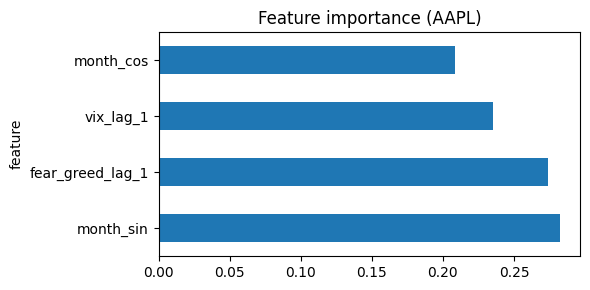

In [89]:
# Feature importance (average across 21 horizon-specific XGB estimators, fitted on first test symbol)
import matplotlib.pyplot as plt
sym = TICKERS[0]
grp = stacked[stacked["symbol"] == sym].sort_values("timestamp").reset_index(drop=True)
feat_df, _, feature_cols_xgb, target_cols = build_feature_df(grp)
if len(feat_df) >= MIN_TRAIN_STACK + FORECAST_HORIZON:
    X = feat_df[feature_cols_xgb].values.astype(np.float32)
    y = feat_df[target_cols].values.astype(np.float32)
    n = len(y)
    train_end = n - FORECAST_HORIZON
    X_train_s = StandardScaler().fit_transform(X[:train_end])
    y_train = y[:train_end]
    xgb_multi = MultiOutputRegressor(XGBRegressor(**XGB_PARAMS))
    xgb_multi.fit(X_train_s, y_train)
    imp = np.mean([est.feature_importances_ for est in xgb_multi.estimators_], axis=0)
    fi_df = pd.DataFrame({"feature": feature_cols_xgb, "importance": imp}).sort_values("importance", ascending=False)
    print("XGBoost feature importance (avg over 21 horizons):")
    print(fi_df.to_string(index=False))
    fi_df.plot(x="feature", y="importance", kind="barh", legend=False, figsize=(6, 3))
    plt.title(f"Feature importance ({sym})")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for feature importance.")

In [90]:
# Save XGBoost model as artifact (model + scaler + feature names for inference)
ARTIFACT_PATH = ARTIFACTS_DIR / "xgboost_pool.joblib"
sym = TICKERS[0]
grp = stacked[stacked["symbol"] == sym].sort_values("timestamp").reset_index(drop=True)
feat_df, _, feature_cols_xgb, target_cols = build_feature_df(grp)
if len(feat_df) >= MIN_TRAIN_STACK + FORECAST_HORIZON:
    X = feat_df[feature_cols_xgb].values.astype(np.float32)
    y = feat_df[target_cols].values.astype(np.float32)
    n = len(y)
    train_end = n - FORECAST_HORIZON
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X[:train_end])
    y_train = y[:train_end]
    xgb_multi = MultiOutputRegressor(XGBRegressor(**XGB_PARAMS))
    xgb_multi.fit(X_train_s, y_train)
    artifact = {
        "model": xgb_multi,
        "scaler": scaler,
        "feature_cols_xgb": feature_cols_xgb,
        "FORECAST_HORIZON": FORECAST_HORIZON,
        "XGB_PARAMS": XGB_PARAMS,
    }
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    joblib.dump(artifact, ARTIFACT_PATH)
    print("Saved artifact:", ARTIFACT_PATH)
else:
    print("Not enough data to save artifact.")

Saved artifact: C:\capstone_project_unfc\model\experiments-pool\artifacts\xgboost_pool.joblib
